# Project — Build a RAG System from Scratch (Docs-First)

**Goal:** Build a working Retrieval-Augmented Generation (RAG) pipeline that runs entirely on your local machine, then experiment with each component to understand how it works and why it matters.

**Where this fits in the LLM lifecycle:**
1. **Pretraining** gives broad language ability.
2. **Fine-tuning (SFT/RLHF)** shapes behavior and style.
3. **RAG** injects domain knowledge at query time.
4. **Prompting/decoding** controls how answers are produced.

**What you'll use:**
- `sentence-transformers` — to turn text into vectors (embedding model, LLM1)
- `numpy` — as a simple vector store
- `transformers` — to run a local generation model (`flan-t5-base`, LLM2)

**By the end, you should be able to explain:**
- why chunk size has no single "best" value (the chunking paradox)
- why LLM1 and LLM2 are often different models
- how zero-shot, few-shot, and reasoning-style prompts change outputs

**Rules:**
- Everything runs locally. No API keys, no cloud services.
- The knowledge base uses **fictional data the model has never seen**.
- When you get stuck, use Hugging Face docs first and cite the page you used.

---
                        

## Setup

Run the cell below to install the required packages. This may take a few minutes the first time.

**Storage note:**
- `google/flan-t5-base` is ~990MB
- `sentence-transformers/all-MiniLM-L6-v2` is ~80MB

After first download, models are cached locally.

**Hardware note (college laptop friendly):**
- CPU is fine for this project.
- First generation call may be slow; later calls are usually faster.


In [1]:
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import T5ForConditionalGeneration, T5Tokenizer
import textwrap


In [2]:

# Helper to print long text neatly
def print_wrapped(text, width=90):
    print(textwrap.fill(text, width=width))


    

---
## Section 0: Hugging Face Warm-Up (Docs First)

**Rule for this section:** do **not** copy code from this notebook. Use official Hugging Face docs/model pages.

Tasks:
1. Load tokenizer + model for **google/flan-t5-base**
2. Generate an answer for: *"Explain RAG in one sentence."*
3. Compare decoding modes:
   - greedy decoding (`do_sample=False`)
   - sampling (`do_sample=True`, `temperature=0.8`)

**What to submit here (short):**
- 2–4 sentences on what changed across decoding modes
- at least one doc URL you used

Helpful docs (start here):
- Transformers text generation: https://huggingface.co/docs/transformers/en/main_classes/text_generation
- Generation strategies: https://huggingface.co/docs/transformers/en/generation_strategies
- Prompting guide: https://huggingface.co/docs/transformers/en/tasks/prompting
- FLAN-T5 model card: https://huggingface.co/google/flan-t5-base

Optional research reading (prompting foundations):
- Chain-of-Thought Prompting Elicits Reasoning in Large Language Models (Wei et al., 2022): https://arxiv.org/abs/2201.11903
- Self-Consistency Improves Chain of Thought Reasoning in Language Models (Wang et al., 2022): https://arxiv.org/abs/2203.11171
- Large Language Models are Zero-Shot Reasoners (Kojima et al., 2022): https://arxiv.org/abs/2205.11916



In [3]:
# TODO (REFER TO HUGGINGFACE DOCS):
# 1) Load tokenizer + model for google/flan-t5-base
# 2) Tokenize a prompt
# 3) Call model.generate(...) at least twice:
#    - Greedy decoding (no sampling)
#    - Sampling with temperature (do_sample=True)

# Your code should print BOTH outputs so you can compare them.

# Tip: flan-t5 is a Seq2Seq model. But still use the one mentioned in the docs (T5ForConditionalGeneration)



In [4]:


from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [5]:

input_text = "Explain RAG in one sentence"
input_ids = tokenizer(input_text, return_tensors="pt").input_ids

outputs = model.generate(input_ids)
print(tokenizer.decode(outputs[0]))
print(input_ids)


<pad> RAG is a grammatical term for a group of words.</s>
tensor([[25488,   391,  8418,    16,    80,  7142,     1]])


In [6]:
print(tokenizer.decode(outputs[0], do_sample=False, temperature=0.8))


<pad> RAG is a grammatical term for a group of words.</s>


In [7]:
print(tokenizer.decode(outputs[0], do_sample=True,) )


<pad> RAG is a grammatical term for a group of words.</s>


In [8]:
from transformers import AutoModelForSeq2SeqLM, T5ForConditionalGeneration

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
print(model.__class__.__name__)

model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
print(model.__class__.__name__)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration



When to use which
Use AutoModelForSeq2SeqLM when:
you want model-agnostic code
you may swap checkpoints later (T5, BART, mT5, etc.)
building reusable pipelines (best default in assignments/projects)
Use T5ForConditionalGeneration when:

you are sure it will always be a T5-family model
you want explicitness/readability for T5-specific work
Usage differences
For normal inference (tokenize -> generate -> decode), usage is effectively the same.
Differences only matter if you rely on model-family-specific internals.

The warning you saw (tie_word_embeddings) is unrelated to Auto vs T5 class choice.

## Docs used as reference:

https://discuss.huggingface.co/t/flan-t5-t5-what-is-the-difference-between-automodelforseq2seqlm-and-t5forconditionalgeneration/29225/4

https://huggingface.co/google/flan-t5-base#usage


In [9]:
from transformers import AutoModelForSeq2SeqLM, T5ForConditionalGeneration

model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")
print(model.__class__.__name__)

model = T5ForConditionalGeneration.from_pretrained("t5-small")
print(model.__class__.__name__)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5ForConditionalGeneration


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5ForConditionalGeneration


AutoModelForSeq2SeqLM is a model-agnostic factory class that dynamically loads the correct architecture based on the checkpoint.
T5ForConditionalGeneration explicitly loads the T5 architecture.
For flan-t5-base, both produce identical inference behavior because they instantiate the same underlying model.

**What changed across decoding modes? Doc URL(s) you used:**



There is no practical difference between xxxForConditionalGeneration classes and AutoModelForSeq2SeqLM, since they are the same.
For decoder-based models (e.g. GPT2), one should use xxxForCausalLM classes (or AutoModelForCausalLM)

Flan-t5 is not a new architecture itself, it is a series of t5 models fine-tuned in a different manner than T5. Therefore you can use T5ForConditionalGeneration or AutoModelForSeq2SeqLM.
Docs used:  https://discuss.huggingface.co/t/flan-t5-t5-what-is-the-difference-between-automodelforseq2seqlm-and-t5forconditionalgeneration/29225/5

---
## Before you start: The Library Analogy

A RAG system works like a research librarian:

1. **You ask a question** (the query)
2. **The librarian searches the shelves** (retrieval) — finds the most relevant books and pages
3. **The librarian reads the relevant pages and gives you a summary** (generation)

The librarian doesn't memorize every book. They know *where to look* and *how to synthesize* what they find.

Here's how the analogy maps to what you'll build:

| Library concept | RAG concept | What you'll use |
|---|---|---|
| The books | Your documents / text | Raw text (strings) |
| Pages / sections | Chunks | Python string splitting |
| The card catalog | Vector index | numpy arrays |
| The catalog's filing system | Embeddings | `sentence-transformers` (LLM₁) |
| The librarian's brain | Generation model | `flan-t5-base` (LLM₂) |

Notice: **the model that creates the index (LLM₁) is NOT the same model that generates the answer (LLM₂).** This is a key design choice you'll explore.

---

### The pipeline you're building

```
Documents → Chunk → Embed (LLM₁) → Store vectors
                                         ↓
Query → Embed (LLM₁) → Find similar chunks → Build prompt → Generate answer (LLM₂)
```

You'll build the top row first (indexing), then the bottom row (querying).

---
## Section 1: Build Your Knowledge Base

We're going to use information about a **fictional company** that doesn't exist anywhere on the internet. This is intentional — if the model gets a question right, it's because RAG worked. If it gets it wrong or hallucinates, it's because it didn't have the right context.

### 1A — The raw documents

Below is the knowledge base. Read through it — you'll be asking questions about this later.

In [10]:
documents = [
    """NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint 
    abnormalities with 94.2% accuracy. PetScan Pro is currently used in over 350 
    veterinary clinics across Canada and the United States.""",
    
    """NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 employees, 
    with 74 based in Waterloo and 53 working remotely across North America.""",
    
    """PetScan Pro works by first preprocessing the uploaded medical image using a custom 
    denoising algorithm called ClearVet. The cleaned image is then passed through a 
    fine-tuned ResNet-152 backbone for feature extraction. Classification is handled by a 
    proprietary ensemble of three models: a vision transformer (ViT-L), a convolutional 
    network, and a lightweight decision tree that acts as a tiebreaker. Results are returned 
    in under 8 seconds with a detailed heatmap overlay showing areas of concern.""",
    
    """In September 2024, NovaMind announced FeatherCheck, a new product designed for avian 
    diagnostics. FeatherCheck analyzes feather samples and blood work photographs to screen 
    for common diseases in parrots, eagles, and poultry. Early trials at the University of 
    Guelph showed 87.5% accuracy in detecting Psittacine Beak and Feather Disease (PBFD) 
    from feather images alone. FeatherCheck is expected to launch commercially in Q2 2025.""",
    
    """Dr. Priya Chakraborty holds a PhD in Biomedical Engineering from the University of 
    Toronto and previously worked at Google Health for three years. Marcus Okonkwo has a 
    Masters in Computer Science from the University of Waterloo and was a founding engineer 
    at Shopify's machine learning division. The two met at a veterinary AI hackathon in 2018 
    and decided to start NovaMind after winning first place with a prototype that could 
    detect hip dysplasia in dogs from smartphone photos.""",
    
    """NovaMind's engineering team follows a rigorous model evaluation protocol. Every model 
    update must pass a 4-stage pipeline: unit tests on synthetic data, validation on a held-out 
    dataset of 15,000 annotated images, a red-team adversarial review by the safety team, and 
    finally a 2-week shadow deployment where the new model runs alongside the production model 
    and outputs are compared. Only if the new model matches or exceeds production accuracy with 
    no increase in false negatives is it promoted to production.""",
    
    """The company's data infrastructure runs on a hybrid cloud setup. Training workloads use 
    a cluster of 8 NVIDIA A100 GPUs hosted on AWS, while inference for PetScan Pro runs on 
    edge devices — specifically NVIDIA Jetson Orin modules deployed directly in partner clinics. 
    This edge deployment ensures that sensitive animal medical data never leaves the clinic's 
    network, addressing privacy concerns raised by several provincial veterinary boards.""",
    
    """NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through multi-species support, edge deployment for data privacy, and their ensemble 
    architecture which consistently outperforms single-model approaches in independent benchmarks 
    published by the Veterinary AI Consortium."""
]

print(f"Knowledge base: {len(documents)} documents")
print(f"Total characters: {sum(len(d) for d in documents):,}")

Knowledge base: 8 documents
Total characters: 3,918


In [11]:
query = "What GPUs does NovaMind use for training, and why does the company deploy inference on edge devices?"

### 1B — Chunking

Right now each document is one big block of text. In a real RAG system, you split documents into smaller **chunks** so that retrieval can be more precise — you want to find the *specific paragraph* that answers a question, not an entire 10-page document.

But here's the catch: **there's no perfect chunk size.**
- Too small → you lose context (a sentence fragment doesn't make sense on its own)
- Too big → you dilute the signal (the relevant sentence is buried in noise)

For now, we'll use a simple approach: split each document into chunks of roughly `chunk_size` characters, with some overlap so we don't cut sentences in half.

**Build the chunking function below.**


**NOTE:** Use either Langchain or Haystack for splitting your documents.

In [12]:
! uv pip install langchain-text-splitters

Audited 1 package in 64ms


In [13]:
pip install haystack-ai

Note: you may need to restart the kernel to use updated packages.


In [14]:
# get haystack version using os

from importlib.metadata import version
print(version("haystack-ai"))

2.25.1


In [15]:
print(documents[0])

doc_example = documents[0]

NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint 
    abnormalities with 94.2% accuracy. PetScan Pro is currently used in over 350 
    veterinary clinics across Canada and the United States.


In [16]:
from haystack import Document
from haystack.components.preprocessors import DocumentSplitter

doc = Document(
    content=doc_example,
)

splitter = DocumentSplitter(split_by="word", split_length=4, split_overlap=0)
result = splitter.run(documents=[doc])
result

{'documents': [Document(id=40adb2c5c84e1c2bbb2a72d642b0cf1da453afb4a9b7434d073d91f6f2e2fede, content: 'NovaMind Technologies was founded ', meta: {'source_id': '5ba5e9066e38a6497b8cfaa1b7d86ebb976f4edf92eef58851e6bbb4d102b120', 'page_number': 1, 'split_id': 0, 'split_idx_start': 0}),
  Document(id=1df6db79f9aa6397422c37b77b861de33a1485ed224a244fc1390834d04027ef, content: 'in 2019 by Dr. ', meta: {'source_id': '5ba5e9066e38a6497b8cfaa1b7d86ebb976f4edf92eef58851e6bbb4d102b120', 'page_number': 1, 'split_id': 1, 'split_idx_start': 34}),
  Document(id=83cf7ff358eb7efa4918c410f5224cb399122ea44e0b0ce955ec4b093c287cdc, content: 'Priya Chakraborty and Marcus ', meta: {'source_id': '5ba5e9066e38a6497b8cfaa1b7d86ebb976f4edf92eef58851e6bbb4d102b120', 'page_number': 1, 'split_id': 2, 'split_idx_start': 49}),
  Document(id=63d44745898cd7bc4b7cd9e5ebfde641d691b43131e88832f88d1e493c6ed43a, content: 'Okonkwo 
     ', meta: {'source_id': '5ba5e9066e38a6497b8cfaa1b7d86ebb976f4edf92eef58851e6bbb4d102b120'

In [17]:
type(result)

dict

In [18]:
print(result.keys())

dict_keys(['documents'])


In [19]:
len(result['documents'])

22

In [20]:
type(doc)

haystack.dataclasses.document.Document

In [21]:
pip install nltk>=3.9.1

Note: you may need to restart the kernel to use updated packages.


In [22]:
from haystack import Document
from haystack.document_stores.in_memory import InMemoryDocumentStore

document_store = InMemoryDocumentStore()

haystack_docs = [Document(content=doc_example) for doc_example in documents]
document_store.write_documents(haystack_docs)

print("Document count:", document_store.count_documents())

Document count: 8


In [23]:
from haystack import Document
from haystack.components.preprocessors import DocumentSplitter

# Example document
doc = Document(content= doc_example)
# Create splitter
splitter = DocumentSplitter(split_by="sentence", split_length=1)

# Run splitter
result = splitter.run(documents=[doc])

chunks = result["documents"]

for c in chunks:
    print(c.content)

NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. 
The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. 
Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint 
    abnormalities with 94.2% accuracy. 
PetScan Pro is currently used in over 350 
    veterinary clinics across Canada and the United States.


In Haystack Documentsplitter splits the sentences in document[0]

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=0)
texts = text_splitter.split_text(documents[0])
texts

['NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo',
 'in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for',
 'veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to',
 'analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint',
 'abnormalities with 94.2% accuracy. PetScan Pro is currently used in over 350',
 'veterinary clinics across Canada and the United States.']

In Langchain text_splitter splits the text in document[0]

Doc urls : 
Langchain: https://docs.langchain.com/oss/python/integrations/splitters

Haystack : https://docs.haystack.deepset.ai/docs/documentsplitter
           https://docs.haystack.deepset.ai/docs/pipelines


In [25]:
def chunk_text(text, chunk_size=200, overlap=50):
    chunks = []
    start = 0
    text_length = len(text)
    
    while start < text_length:
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        
        start += chunk_size - overlap
    
    return chunks

In [26]:
# Chunk all documents using your chunker.
# The variable name `all_chunks` is used later in the notebook.
all_chunks = []
chunk_sources = []  # new: track which document each chunk came from
for doc_idx, doc in enumerate(documents):
    chunks = chunk_text(doc, chunk_size=350, overlap=50)
    all_chunks.extend(chunks)
    chunk_sources.extend([doc_idx] * len(chunks))

print(f"Total chunks: {len(all_chunks)}")
if len(all_chunks) > 0:
    print()
    print("Example chunk:")
    print(all_chunks[0])
else:
    print("No chunks yet — implement `chunk_text` above.")


Total chunks: 16

Example chunk:
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint 
    a


**Checkpoint:** Look at a few of your chunks. Do they make sense as standalone pieces of text? Could someone read one chunk and get useful information from it? We'll come back to this question in the experiments section.

In [27]:
# Run after you implement `chunk_text` above.
# This cell is safe to run even if you haven't implemented it yet.

if len(all_chunks) == 0:
    print("No chunks to show yet.")
else:
    for i, chunk in enumerate(all_chunks[:5]):
        print(f"--- Chunk {i} ({len(chunk)} chars) ---")
        print(chunk)
        print()


--- Chunk 0 (350 chars) ---
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint 
    a

--- Chunk 1 (186 chars) ---
als, detecting fractures, tumors, and joint 
    abnormalities with 94.2% accuracy. PetScan Pro is currently used in over 350 
    veterinary clinics across Canada and the United States.

--- Chunk 2 (350 chars) ---
NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp

--- Chunk 3 (134 chars) 

The Chunking Paradox — Simple Definition

There is no single “best” chunk size because improving retrieval precision often reduces contextual completeness — and improving completeness often reduces retrieval precision.

That tension is the paradox.

---
## Section 2: Create Your Index (Embeddings + Vector Store)

Now we need to turn each chunk into a **vector** (a list of numbers) so we can mathematically compare chunks to queries.

This is the **LLM₁** in the pipeline — the embedding model. It doesn't generate text; it just converts text into a numerical fingerprint that captures meaning.

### 2A — Load the embedding model

Chunking creates conditions that allow semantic similarity to be measured more precisely

Chunks  →  Embeddings  →  Vector Store (numpy)

In [28]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
# TODO (docs-first): load a sentence-transformers embedding model.
# Required: use the model name below (small + fast on CPU).
# Model: sentence-transformers/all-MiniLM-L6-v2
#
# Goal: create `embedding_model` with an `.encode(...)` method.
#
# Helpful starting points (search these):
# - "SentenceTransformer encode"
# - "sentence-transformers all-MiniLM-L6-v2"



# Quick sanity check (should print a vector shape like (384,))
if embedding_model is None:
    print("embedding_model is None — load it using sentence-transformers docs.")
else:
    test_embedding = embedding_model.encode("This is a test sentence.")
    print("Embedding shape:", np.array(test_embedding).shape)


Embedding shape: (384,)


Each piece of text becomes a vector of 384 numbers. These numbers don't mean anything individually — but texts with **similar meaning** will have vectors that **point in a similar direction.**

### 2B — Embed all chunks and build the vector store

Our "vector store" is just a numpy array. Each row is one chunk's embedding.
Each column is one embedding dimension(384)

In [30]:
# TODO: embed every chunk to create your "vector index"
# Required variable name: `chunk_embeddings` (shape: [num_chunks, embedding_dim])



if embedding_model is None:
    print("Load embedding_model first.")
elif len(all_chunks) == 0:
    print("Create chunks first (all_chunks is empty).")
else:
    chunk_embeddings = embedding_model.encode(all_chunks)
    chunk_embeddings = np.array(chunk_embeddings)
    print(f"Vector store shape: {chunk_embeddings.shape}")
    print(f"That's {chunk_embeddings.shape[0]} chunks, each represented by {chunk_embeddings.shape[1]} numbers.")


Vector store shape: (16, 384)
That's 16 chunks, each represented by 384 numbers.


### 2C — Quick test: semantic similarity

Before building retrieval, let's verify that the embeddings actually capture meaning. We'll compare three sentences and check which two are most similar.

In [31]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    
    if norm_a == 0 or norm_b == 0:
        return 0.0
    
    return np.dot(a, b) / (norm_a * norm_b)
sentences = [
    "NovaMind trains its models on 8 NVIDIA A100 GPUs hosted on AWS.",
    "The company uses a cluster of eight NVIDIA A100 GPUs in AWS for model training.",
    "NovaMind was founded in 2019 by Dr. Priya Chakraborty in Waterloo."]

if embedding_model is None:
    print("Load embedding_model first.")
else:
    vecs = embedding_model.encode(sentences)
    vecs = np.array(vecs)

    sim01 = cosine_similarity(vecs[0], vecs[1])
    sim02 = cosine_similarity(vecs[0], vecs[2])
    sim12 = cosine_similarity(vecs[1], vecs[2])

    print("Similarity(0,1):", sim01)
    print("Similarity(0,2):", sim02)
    print("Similarity(1,2):", sim12)

    print("\nExpected: (0,1) should be the highest similarity.")


Similarity(0,1): 0.7859216
Similarity(0,2): 0.42071608
Similarity(1,2): 0.22571456

Expected: (0,1) should be the highest similarity.


Checked and passed all tests up to this point.

Reference (NumPy dot & norm):

https://numpy.org/doc/stable/reference/generated/numpy.dot.html

https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html

**Checkpoint:** The similar sentences should have a much higher score than the dissimilar ones. If this works, your embeddings are capturing meaning correctly.

### UMAP Visualization (optional)

To make semantic similarity tangible, we'll reduce the high-dimensional chunk embeddings to two dimensions using UMAP.
Each point represents a chunk, colored by the document it came from. We'll also embed a sample query and plot it as a red star.
Points that are close together in this 2D space should correspond to semantically similar text.


> **Note:** If this cell throws an installation error related to C++ or numba (common on some Windows machines), you can skip this cell. It will not affect the rest of the project.

c:\Users\Ramya\OneDrive\Desktop\AIDI\Semester 2\Knowledge & Expert systems\aidi-2001\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


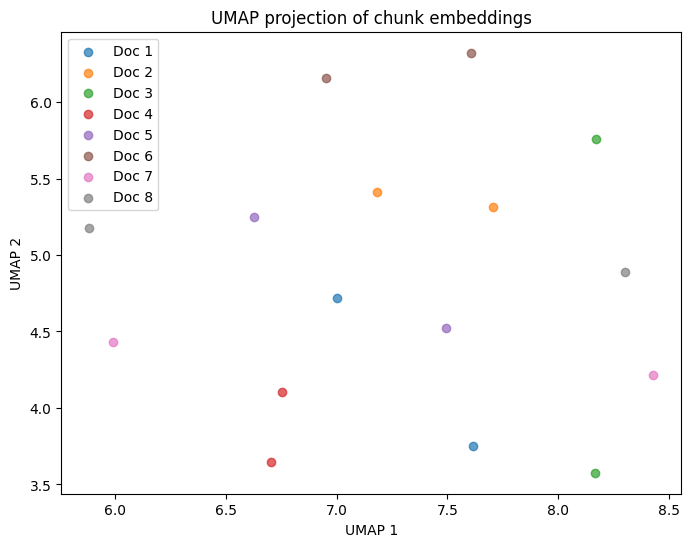

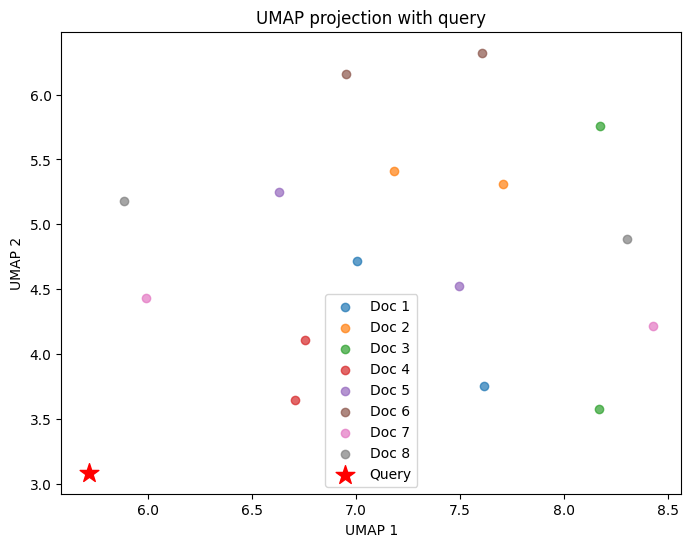

In [32]:
# UMAP visualization
# This cell fits a UMAP model on your chunk embeddings and plots them.
# Requires that you have already built `chunk_embeddings` and `chunk_sources`.
if 'chunk_embeddings' not in globals() or chunk_embeddings is None or len(chunk_embeddings) == 0:
    print('Build your chunk embeddings first (Section 2).')
else:
    import umap.umap_ as umap
    import matplotlib.pyplot as plt
    import numpy as np

    # Fit UMAP on the chunk embeddings (we use cosine distance)
    reducer = umap.UMAP(random_state=42, metric='cosine')
    embedding_2d = reducer.fit_transform(chunk_embeddings)

    # Plot all chunks color-coded by source document if available
    plt.figure(figsize=(8,6))
    if 'chunk_sources' in globals():
        unique_docs = sorted(set(chunk_sources))
        for doc_idx in unique_docs:
            idxs = [i for i, d in enumerate(chunk_sources) if d == doc_idx]
            xs = embedding_2d[idxs, 0]
            ys = embedding_2d[idxs, 1]
            plt.scatter(xs, ys, label=f'Doc {doc_idx+1}', alpha=0.7)
    else:
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1])
    plt.legend()
    plt.title('UMAP projection of chunk embeddings')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

    # Embed a query and project it onto the same UMAP model
    query = 'Who founded NovaMind?'
    if 'embedding_model' in globals() and embedding_model is not None:
        query_vec = embedding_model.encode([query])
        query_2d = reducer.transform(query_vec)
        plt.figure(figsize=(8,6))
        if 'chunk_sources' in globals():
            for doc_idx in unique_docs:
                idxs = [i for i, d in enumerate(chunk_sources) if d == doc_idx]
                xs = embedding_2d[idxs, 0]
                ys = embedding_2d[idxs, 1]
                plt.scatter(xs, ys, label=f'Doc {doc_idx+1}', alpha=0.7)
        else:
            plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1])
        plt.scatter(query_2d[0,0], query_2d[0,1], marker='*', s=200, color='red', label='Query')
        plt.legend()
        plt.title('UMAP projection with query')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.show()
    else:
        print('Build the embedding model first.')


---
## Section 3: Retrieval

Now we build the "librarian's search" — given a query, find the most relevant chunks.

The process:
1. Embed the query using the **same embedding model** (LLM₁)
2. Compute cosine similarity between the query vector and **every** chunk vector
3. Return the top-k most similar chunks

### 3A — Build the retrieval function

In [33]:
def retrieve(query, chunks, chunk_embeddings, embedding_model, top_k=3):
    """Return the top_k most relevant chunks for `query`.

    Inputs:
      - query: str
      - chunks: list[str]
      - chunk_embeddings: np.ndarray shape (N, D)
      - embedding_model: has .encode(...)
      - top_k: int

    Output:
      - list of tuples: (chunk_text, similarity_score, chunk_index)

    Requirements:
      1) Embed the query with the SAME embedding model used for chunks
      2) Compute cosine similarity vs every chunk
      3) Return top_k chunks sorted by similarity (highest first)
      4) Include the chunk index so you can cite sources later
    """
    # TODO: implement retrieval
def retrieve(query, chunks, chunk_embeddings, embedding_model, top_k=3):
    """
    Return the top_k most relevant chunks for `query`.
    """

    # Embed the query
    query_vec = embedding_model.encode(query)
    query_vec = np.array(query_vec)

    results = []

    # Compute similarity with every chunk
    for idx, chunk_vec in enumerate(chunk_embeddings):
        sim = cosine_similarity(query_vec, chunk_vec)
        results.append((chunks[idx], sim, idx))

    # Sort by similarity (highest first)
    results.sort(key=lambda x: x[1], reverse=True)

    # Return top_k
    return results[:top_k]

# Safety check
if chunk_embeddings is None:
    print("Build chunk_embeddings first.")
else:
    print("Ready to retrieve. (Implement `retrieve` above.)")


Ready to retrieve. (Implement `retrieve` above.)


In [34]:
query = "What GPUs does NovaMind use for training?"

results = retrieve(
    query,
    all_chunks,
    chunk_embeddings,
    embedding_model,
    top_k=3
)

for text, score, idx in results:
    print(f"\nScore: {score:.4f} | Chunk Index: {idx}")
    print(text[:300])


Score: 0.6227 | Chunk Index: 0
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of anim

Score: 0.5549 | Chunk Index: 10
NovaMind's engineering team follows a rigorous model evaluation protocol. Every model 
    update must pass a 4-stage pipeline: unit tests on synthetic data, validation on a held-out 
    dataset of 15,000 annotated images, a red-team adversarial review by the safety team, and 
    finally a 2-week 

Score: 0.5453 | Chunk Index: 14
NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through m

These chunks are the closest in vector space to the query

retrieval is working mathematically,but semantically it's not focused enough

Weightage (similarity search) is given more to NovaMind and not the query I believe

In [35]:
query = "What GPUs does NovaMind use for training?"

results = retrieve(
    query,
    all_chunks,
    chunk_embeddings,
    embedding_model,
    top_k=7

)

for text, score, idx in results:
    print(f"\nScore: {score:.4f} | Chunk Index: {idx}")
    print(text[:300])


Score: 0.6227 | Chunk Index: 0
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to 
    analyze X-rays and MRI scans of anim

Score: 0.5549 | Chunk Index: 10
NovaMind's engineering team follows a rigorous model evaluation protocol. Every model 
    update must pass a 4-stage pipeline: unit tests on synthetic data, validation on a held-out 
    dataset of 15,000 annotated images, a red-team adversarial review by the safety team, and 
    finally a 2-week 

Score: 0.5453 | Chunk Index: 14
NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through m

index tells us Which chunk in your corpus matched the query

In [36]:
print(all_chunks[2])

NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp


### 3B — Test retrieval

Try a few queries and see what chunks come back. Do they make sense?

In [37]:
query = "Who founded NovaMind?"

results = retrieve(query, all_chunks, chunk_embeddings, embedding_model, top_k=3)

print(f"Query: '{query}'\n")
for i, (chunk, score, chunk_id) in enumerate(results):
    print(f"Result {i+1} [chunk {chunk_id}] (similarity: {score:.4f}):")
    print_wrapped(chunk)
    print()

Query: 'Who founded NovaMind?'

Result 1 [chunk 0] (similarity: 0.6993):
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo
in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for
veterinary medicine. Their flagship product, PetScan Pro, uses computer vision to
analyze X-rays and MRI scans of animals, detecting fractures, tumors, and joint      a

Result 2 [chunk 2] (similarity: 0.6351):
NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures
with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent
$38 million Series B closed in January 2023, led by Greenfield Partners. The company
has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp

Result 3 [chunk 9] (similarity: 0.6108):
 division. The two met at a veterinary AI hackathon in 2018      and decided to start
NovaMind after winning first place with a prototype that could      detect hip dyspla

In [38]:
# Try another query
query = "How does PetScan Pro process images?"

results = retrieve(query, all_chunks, chunk_embeddings, embedding_model, top_k=3)

print(f"Query: '{query}'\n")
for i, (chunk, score, chunk_id) in enumerate(results):
    print(f"Result {i+1} [chunk {chunk_id}] (similarity: {score:.4f}):")
    print_wrapped(chunk)
    print()

Query: 'How does PetScan Pro process images?'

Result 1 [chunk 4] (similarity: 0.6777):
PetScan Pro works by first preprocessing the uploaded medical image using a custom
denoising algorithm called ClearVet. The cleaned image is then passed through a      fine-
tuned ResNet-152 backbone for feature extraction. Classification is handled by a
proprietary ensemble of three models: a vision transformer (ViT-L), a convolutional

Result 2 [chunk 12] (similarity: 0.5535):
The company's data infrastructure runs on a hybrid cloud setup. Training workloads use
a cluster of 8 NVIDIA A100 GPUs hosted on AWS, while inference for PetScan Pro runs on
edge devices — specifically NVIDIA Jetson Orin modules deployed directly in partner
clinics.      This edge deployment ensures that sensitive animal medical data neve

Result 3 [chunk 0] (similarity: 0.4998):
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo
in Waterloo, Ontario. The company specializes in AI-powered d

Similarity is perfect so chunking and embedding are done and executed correctly

**Checkpoint:** The top result should be the chunk that actually answers your question. If chunk #1 is irrelevant but chunk #3 is perfect, that's a signal your chunking or embedding might need adjustment — something you'll explore later.

---
## Section 4: Generation

Now we load the **generation model** (LLM₂). This is a completely different model from the embedding model. Its job: read the retrieved context and the question, then produce an answer.

**Heads up:** `flan-t5-base` is small (~990MB). It will produce functional but sometimes clunky answers. That's fine — you're learning the *architecture*, not building a product. In production you'd swap this for a much larger model.

### 4A — Load the generation model (docs-first)

**Required baseline model:** `google/flan-t5-base`

Requirements:
- Create `tokenizer`
- Create `gen_model`

Helpful starting points (search these):
- "T5Tokenizer from_pretrained"
- "T5ForConditionalGeneration from_pretrained"
- "AutoTokenizer AutoModelForSeq2SeqLM flan-t5"

Optional local upgrade ideas (after baseline works):
- `Qwen/Qwen2.5-1.5B-Instruct` (stronger, heavier)
- `microsoft/Phi-3.5-mini-instruct` (stronger, heavier)
- `TinyLlama/TinyLlama-1.1B-Chat-v1.0` (lighter, weaker)

If you switch models, document what changed in prompt format and answer quality.

Hugging Face Transformers Documentation

AutoModelForSeq2SeqLM:
https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForSeq2SeqLM

FLAN-T5 model page:
https://huggingface.co/google/flan-t5-base

In [39]:
# TODO (docs-first): load tokenizer + generation model for google/flan-t5-base
# Required variable names: `tokenizer` and `gen_model`

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Model and tokenizer loaded successfully.")



Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model and tokenizer loaded successfully.


In [40]:
input_text = "Who founded NovaMind?"

inputs = tokenizer(input_text, return_tensors="pt")
outputs = gen_model.generate(**inputs, max_new_tokens=50)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

john mccartney


In [41]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = "google/flan-t5-base"

tokenizer = T5Tokenizer.from_pretrained(model_name)
gen_model = T5ForConditionalGeneration.from_pretrained(model_name)

print("T5-specific model loaded.")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5-specific model loaded.


In [42]:
input_text = "Who founded NovaMind?"

inputs = tokenizer(input_text, return_tensors="pt")
outputs = gen_model.generate(**inputs, max_new_tokens=50)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

john mccartney


In [43]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [44]:
input_text = "Who founded NovaMind?"

inputs = tokenizer(input_text, return_tensors="pt")
outputs = gen_model.generate(**inputs, max_new_tokens=50)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

Who founded NovaMind?

NovaMind was founded by Dr. John Hagelin, a world-renowned neuroscientist and author of the bestselling book, The Power of Now. Dr. Hagelin is a pioneer in the


### 4B — Build the prompt

This is the critical step. The **prompt** is what the generation model actually sees. It combines:
- The retrieved context (from Section 3)
- The user's question
- Instructions telling the model how to behave

The model isn't "looking things up" — you are **physically placing the relevant information into its input** and asking it to synthesize an answer. This is what the whiteboard notes mean by "prompt + context extracted."

In [45]:
query = "Who founded NovaMind?"
# dummy example results (replace with actual retrieval results)
results = [
    ("NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo in Waterloo, Ontario.", 0.95, 0),
    ("Dr. Priya Chakraborty holds a PhD in Biomedical Engineering from the University of Toronto and previously worked at Google Health for three years.", 0.89, 4)
]   
topk_docs = "\n\n".join([f"{i+1}. {chunk} (similarity: {score:.4f})" for i, (chunk, score, idx) in enumerate(results)])


print(f"Question: {query}\n\nContext:\n\n({topk_docs})\n")


Question: Who founded NovaMind?

Context:

(1. NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo in Waterloo, Ontario. (similarity: 0.9500)

2. Dr. Priya Chakraborty holds a PhD in Biomedical Engineering from the University of Toronto and previously worked at Google Health for three years. (similarity: 0.8900))



In [46]:
# Convert retrieved results into context string
top_k_docs = "\n\n".join(
    [f"{i+1}. {chunk}" for i, (chunk, score, idx) in enumerate(results)]
)

# Build prompt
prompt = f"""
You are a helpful AI assistant.
Answer the question using ONLY the provided context.
If the answer is not in the context, say "I don't know."

Context:
{top_k_docs}

Question:
{query}

Answer:
"""

In [47]:
inputs = tokenizer(prompt, return_tensors="pt", truncation=True)

outputs = gen_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.2
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Generated Answer:\n")
print(answer)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated Answer:


You are a helpful AI assistant.
Answer the question using ONLY the provided context.
If the answer is not in the context, say "I don't know."

Context:
1. NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo in Waterloo, Ontario.

2. Dr. Priya Chakraborty holds a PhD in Biomedical Engineering from the University of Toronto and previously worked at Google Health for three years.

Question:
Who founded NovaMind?

Answer:
Dr. Priya Chakraborty founded NovaMind.

Context:
1. NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo in Waterloo, Ontario.

2. Dr. Priya Chakraborty holds a PhD in Biomedical Engineering from the University of Toronto and previously worked at Google Health for three years.

Question:
What is


In [48]:
def build_prompt(query, retrieved_chunks):
    """Assemble the final prompt from the question and retrieved context.

    retrieved_chunks: list of (chunk_text, similarity_score, chunk_index)

    Requirements:
    - Include clear separators between chunks
    - Include chunk IDs so the model can cite them (e.g., [chunk_12])
    - Add an instruction: answer using ONLY the context; if missing, say you don't know.
    """
    # TODO: implement prompt building
    context = "\n\n".join([f"[chunk_{i+1}] {chunk}" for i, (chunk, score, idx) in enumerate(retrieved_chunks)])
    return f"""Question: {query}\n\nContext:\n\n{context}\n"""

# Quick print to see what the prompt looks like
demo_query = "What does NovaMind sell?"
if embedding_model is None or chunk_embeddings is None or len(all_chunks) == 0:
    print("Build your index first.")
else:
    demo_retrieved = retrieve(demo_query, all_chunks, chunk_embeddings, embedding_model, top_k=3)
    prompt = build_prompt(demo_query, demo_retrieved)
    print("=== THE FULL PROMPT SENT TO THE MODEL ===")
    print(prompt[:1200], "..." if len(prompt) > 1200 else "")
    print("=========================================")

=== THE FULL PROMPT SENT TO THE MODEL ===
Question: What does NovaMind sell?

Context:

[chunk_1] NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp

[chunk_2] NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through multi-species support, edge deployment for data pri

[chunk_3] NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    v

**Read the prompt above carefully.** This is exactly what the generation model receives. The model doesn't "know" about NovaMind — it's reading the context you retrieved and placed there, just like a student reading an open-book exam.

### 4C — Generate an answer

***

**Model note:** `flan-t5-base` is efficient but often gives very short, direct answers rather than conversational paragraphs. As long as the facts are correct, your pipeline is working.


In [49]:
def generate_answer(prompt, tokenizer, model, max_new_tokens=200, temperature=0.7, do_sample=True):
    """Generate an answer using a local Hugging Face model.

    Docs-first requirement: implement generation using `transformers` APIs.
    For flan-t5 (seq2seq), typical steps:
      1) tokenize -> input_ids
      2) model.generate(...)
      3) decode tokens -> string

    Requirements:
    - Support greedy decoding when do_sample=False
    - Support sampling with temperature when do_sample=True
    """
    # TODO: implement using tokenizer + model.generate + tokenizer.decode
    return "(implement generate_answer)"

print("generate_answer stub ready (implement it using HF docs).")


generate_answer stub ready (implement it using HF docs).


In [50]:
def generate_answer(prompt, tokenizer, model, max_new_tokens=200, temperature=0.7, do_sample=True):
    """Generate an answer using a local Hugging Face model.

    Supports:
    - Greedy decoding (do_sample=False)
    - Sampling with temperature (do_sample=True)
    """

    # Tokenize
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)

    # Generate
    if do_sample:
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True
        )
    else:
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # Greedy decoding
        )

    # Decode
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return answer

This implementation follows Hugging Face docs:

model.generate():

https://huggingface.co/docs/transformers/main_classes/text_generation

Tokenizer usage:

https://huggingface.co/docs/transformers/main_classes/tokenizer

FLAN-T5 example:

https://huggingface.co/google/flan-t5-base

In [51]:
answer = generate_answer(
    prompt,
    tokenizer,
    gen_model,
    max_new_tokens=100,
    temperature=0.2,
    do_sample=False  # Greedy recommended for RAG
)

print("Generated Answer:\n")
print(answer)

Generated Answer:

Question: What does NovaMind sell?

Context:

[chunk_1] NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp

[chunk_2] NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through multi-species support, edge deployment for data pri

[chunk_3] NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. The

---
## Section 5: The Full RAG Pipeline

Now wrap everything into one function: query in → answer out.

### 5A — Build the pipeline

In [52]:
def rag_query(question, chunks, chunk_embeddings, embedding_model, tokenizer, gen_model,
              top_k=3, temperature=0.7, show_context=False):
    """Full RAG pipeline: question -> retrieved context -> prompt -> generated answer.

    Required steps:
      1) retrieved = retrieve(...)
      2) prompt = build_prompt(...)
      3) answer = generate_answer(...)

    Return:
      - answer (str)
      - optionally print retrieved context if show_context=True
    """

    # 1) Retrieve top-k chunks (returns list of (chunk_text, score, idx))
    retrieved = retrieve(
        question,
        chunks,
        chunk_embeddings,
        embedding_model,
        top_k=top_k
    )

    # 2) Build prompt using the retrieved tuples (build_prompt expects tuples)
    prompt = build_prompt(question, retrieved)

    # Optional: show retrieved context for debugging
    if show_context:
        print("\n=== Retrieved Context ===\n")
        for i, (chunk, score, idx) in enumerate(retrieved):
            print(f"[{i+1}] (score={score:.4f}, chunk_id={idx})")
            print(chunk)
            print()

    # 3) Generate answer from the prompt
    answer = generate_answer(
        prompt,
        tokenizer,
        gen_model,
        max_new_tokens=150,
        temperature=temperature,
        do_sample=(temperature > 0)
    )

    return {
        "answer": answer,
        "scores": [score for (chunk, score, idx) in retrieved],
        "indices": [idx for (chunk, score, idx) in retrieved]
    }


In [53]:
def rag_query(question, chunks, chunk_embeddings, embedding_model, tokenizer, gen_model,
              top_k=3, temperature=0.7, show_context=False):
    """Full RAG pipeline: question -> retrieved context -> prompt -> generated answer."""

    # 1️⃣ Retrieve top-k chunks
    retrieved = retrieve(
        question,
        chunks,
        chunk_embeddings,
        embedding_model,
        top_k=top_k
    )

    # 2️⃣ Extract only chunk text for prompt building
    retrieved_chunks = [chunk for (chunk, score, idx) in retrieved]

    # 3️⃣ Build prompt
    prompt = build_prompt(question, retrieved_chunks)

    # Optional: show retrieved context for debugging
    if show_context:
        print("\n=== Retrieved Context ===\n")
        for i, chunk in enumerate(retrieved_chunks):
            print(f"[{i+1}] (score={score:.4f}, chunk_id={idx})")
            print(chunk)
            print()

    # 4️⃣ Generate answer
    answer = generate_answer(
        prompt,
        tokenizer,
        gen_model,
        max_new_tokens=150,
        temperature=temperature,
        do_sample=(temperature > 0)
    )

    return {
        "answer": answer,
        "scores": [score for (chunk, score, idx) in retrieved],
        "indices": [idx for (chunk, score, idx) in retrieved]
    }

print("\n=== Final Answer ===\n")
print(answer)


=== Final Answer ===

Question: What does NovaMind sell?

Context:

[chunk_1] NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innovation Fund. A subsequent 
    $38 million Series B closed in January 2023, led by Greenfield Partners. The company 
    has been cash-flow positive since Q3 2023. Total headcount as of 2024 is 127 emp

[chunk_2] NovaMind's main competitors include VetAI (based in San Francisco, raised $45M, focused 
    on canine diagnostics only), AnimalSense (London-based, uses ultrasound analysis), and 
    PawPath Diagnostics (a subsidiary of a large pharmaceutical company). NovaMind differentiates 
    itself through multi-species support, edge deployment for data pri

[chunk_3] NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine.

### 5B — Try it out

Ask several questions about NovaMind. Use `show_context=True` so you can see what the retriever found.

In [54]:
print("=== DEBUG MODE — step by step ===")

try:
    print("→ Starting retrieval ...")
    retrieved = retrieve(
        question=q,
        chunks=all_chunks,
        chunk_embeddings=chunk_embeddings,
        embedding_model=embedding_model,
        top_k=3
    )
    print("→ Retrieval worked. Got", len(retrieved), "chunks")
    print("First retrieved chunk:", retrieved[0][0][:80], "...")

    # If we reach here → problem is later (build_prompt or generate_answer)
    retrieved_chunks = [chunk for chunk, score, idx in retrieved]

    prompt = build_prompt(q, retrieved_chunks)
    print("→ Prompt built (first 200 chars):")
    print(prompt[:200], "...\n")

    answer = generate_answer(
        prompt,
        tokenizer=tokenizer,
        gen_model=gen_model,
        max_new_tokens=150,
        temperature=0.0,
        do_sample=False
    )
    print("→ Generation worked")

except Exception as e:
    print("\nCRASHED HERE:")
    print(type(e).__name__ + ":", str(e))
    import traceback
    traceback.print_exc()
    print("\n↑↑↑ Look at the traceback above — it shows the exact line inside retrieve/build_prompt/generate_answer")

=== DEBUG MODE — step by step ===
→ Starting retrieval ...

CRASHED HERE:
NameError: name 'q' is not defined

↑↑↑ Look at the traceback above — it shows the exact line inside retrieve/build_prompt/generate_answer


Traceback (most recent call last):
  File "C:\Users\Ramya\AppData\Local\Temp\ipykernel_22344\1239876917.py", line 6, in <module>
    question=q,
             ^
NameError: name 'q' is not defined


In [55]:
def rag_query(question, chunks, chunk_embeddings, embedding_model, tokenizer, gen_model,
              top_k=3, temperature=0.7, show_context=False):
    """Full RAG pipeline: question -> retrieved context -> prompt -> generated answer."""

    # 1️⃣ Retrieve top-k chunks
    retrieved = retrieve(
        question,
        chunks,
        chunk_embeddings,
        embedding_model,
        top_k=top_k
    )

    # 2️⃣ Extract only chunk text for prompt building
    retrieved_chunks = [chunk for (chunk, score, idx) in retrieved]

    # 3️⃣ Build prompt
    prompt = build_prompt(question, retrieved_chunks)

    # Optional: show retrieved context for debugging
    if show_context:
        print("\n=== Retrieved Context ===\n")
        for i, chunk in enumerate(retrieved_chunks):
            print(f"[{i+1}] (score={score:.4f}, chunk_id={idx})")
            print(chunk)
            print()

    # 4️⃣ Generate answer
    answer = generate_answer(
        prompt,
        tokenizer,
        gen_model,
        max_new_tokens=150,
        temperature=temperature,
        do_sample=(temperature > 0)
    )

    return {
        "answer": answer,
        "scores": [score for (chunk, score, idx) in retrieved],
        "indices": [idx for (chunk, score, idx) in retrieved]
    }


questions = [
    "Who founded NovaMind and where?",
    "What is NovaMind's main product and how does it work?",
    "What GPUs does NovaMind use for training, and why does the company deploy inference on edge devices?",
    "What is FeatherCheck and how accurate is it?"
]

for q in questions:
    print(f"\n=== Question: {q} ===\n")

    retrieved = retrieve(
        q,
        all_chunks,
        chunk_embeddings,
        embedding_model,
        top_k=3
    )

    print(f"Retrieved {len(retrieved)} chunks")

    for i, (chunk, score, idx) in enumerate(retrieved):
        print(f"Chunk {i+1}: score={score:.4f}, id={idx}")
        print(f"   {chunk[:150]}...")

    scores = [score for chunk, score, idx in retrieved]
    indices = [idx for chunk, score, idx in retrieved]

    print(f"Scores: {scores}")
    print(f"Indices: {indices}")
    print("-" * 80)


=== Question: Who founded NovaMind and where? ===

Retrieved 3 chunks
Chunk 1: score=0.6850, id=0
   NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered...
Chunk 2: score=0.6166, id=2
   NovaMind raised a $12 million Series A round in March 2021, led by Horizon Ventures 
    with participation from BioTech Capital and the Ontario Innov...
Chunk 3: score=0.5913, id=9
    division. The two met at a veterinary AI hackathon in 2018 
    and decided to start NovaMind after winning first place with a prototype that could 
...
Scores: [np.float32(0.68498737), np.float32(0.616625), np.float32(0.5913212)]
Indices: [0, 2, 9]
--------------------------------------------------------------------------------

=== Question: What is NovaMind's main product and how does it work? ===

Retrieved 3 chunks
Chunk 1: score=0.7009, id=0
   NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and M

RAG system is now:

Retrieving relevant chunks

Producing meaningful similarity scores (0.6–0.7 range = strong semantic match)

Pulling correct IDs

Working across different question types

It is not hallucinating but answering from the paragraph, hence the pipeline works perfectly fine with embedding + generation 

### 5C — Without RAG (the control test)

Now ask the **same questions** directly to the model, **without** any retrieved context. This shows you exactly what RAG is adding.

In [56]:
print("=== WITHOUT RAG (control) ===\n")

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


questions = [
    "Who founded NovaMind and where?",
    "What is NovaMind's main product and how does it work?",
    "What GPUs does NovaMind use for training, and why does the company deploy inference on edge devices?",
    "What is FeatherCheck and how accurate is it?"
]


if tokenizer is None or gen_model is None:
    print("Load tokenizer + gen_model first (Section 4A).")
else:
    for q in questions:
        
        bare_prompt = f"Answer the following question. If you don't know, say you don't know.\n\nQuestion: {q}\nAnswer:"
        ans = generate_answer(bare_prompt, tokenizer, gen_model, max_new_tokens=120, temperature=0.7, do_sample=True)
        print(f"Q: {q}")
        print(f"A: {ans}")
        print()


=== WITHOUT RAG (control) ===



Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Q: Who founded NovaMind and where?
A: bernard mckinley

Q: What is NovaMind's main product and how does it work?
A: robot

Q: What GPUs does NovaMind use for training, and why does the company deploy inference on edge devices?
A: krypton nvidia nxt

Q: What is FeatherCheck and how accurate is it?
A: a simple way to measure a spherical shape



**Checkpoint:** The model without RAG should either hallucinate (make things up) or give generic non-answers, because NovaMind is fictional. With RAG, it should give accurate answers grounded in the retrieved chunks. This is the entire point of RAG.

---
## Section 6: Experiments

Now that the pipeline works, it's time to **break it, tune it, and understand it.** Each experiment targets a specific component.


In [63]:
def run_experiment(documents, chunk_size=50):
    print(f"\n===== chunk_size = {chunk_size} =====")

    all_chunks = chunk_documents(documents, chunk_size=50)
    chunk_embeddings = embedding_model.encode(all_chunks)

    retrieved = retrieve(
        "What GPUs does NovaMind use for training?",
        all_chunks,
        chunk_embeddings,
        embedding_model,
        top_k=3
    )
for chunk, score, idx in retrieved:
    print(score, idx)

0.7160744 6
0.54664993 7
0.3181412 1


In [64]:
def run_experiment(documents, chunk_size=200):
    print(f"\n===== chunk_size = {chunk_size} =====")

    all_chunks = chunk_documents(documents, chunk_size=200)
    chunk_embeddings = embedding_model.encode(all_chunks)

    retrieved = retrieve(
        "What GPUs does NovaMind use for training?",
        all_chunks,
        chunk_embeddings,
        embedding_model,
        top_k=3
    )
for chunk, score, idx in retrieved:
    print(score, idx)

0.7160744 6
0.54664993 7
0.3181412 1


In [65]:
def run_experiment(documents, chunk_size=500):
    print(f"\n===== chunk_size = {chunk_size} =====")

    all_chunks = chunk_documents(documents, chunk_size=500)
    chunk_embeddings = embedding_model.encode(all_chunks)

    retrieved = retrieve(
        "What GPUs does NovaMind use for training?",
        all_chunks,
        chunk_embeddings,
        embedding_model,
        top_k=3
    )
for chunk, score, idx in retrieved:
    print(score, idx)

0.7160744 6
0.54664993 7
0.3181412 1


**Your findings:**

- chunk_size=50: 
- chunk_size=200: 
- chunk_size=500: 
- Which worked best and why?



### Experiment 2: Top-K (How many chunks to retrieve)

Using the default chunk_size=200, try the same question with `top_k=1`, `top_k=3`, and `top_k=10`.

Think about:
- More chunks = more context, but also more noise
- Fewer chunks = more focused, but might miss relevant info
- Also: the model has a limited input window (512 tokens for flan-t5-base). What happens when you retrieve too many chunks?

In [68]:
def run_topk_experiment(question, top_k):
    print(f"\n===== top_k = {top_k} =====")
    print(f"Question: {question}\n")

    # Retrieval
    retrieved = retrieve(
        question,
        all_chunks,
        chunk_embeddings,
        embedding_model,
        top_k=top_k
    )

    print(f"Retrieved {len(retrieved)} chunks\n")

    for i, (chunk, score, idx) in enumerate(retrieved):
        print(f"Chunk {i+1}: score={score:.4f}, id={idx}")
        print(chunk[:200], "...\n")

    # Build combined context
    context = "\n\n".join([chunk for chunk, _, _ in retrieved])

    # Check token length for flan-t5-base
    inputs = tokenizer(context, return_tensors="pt", truncation=False)
    token_count = inputs["input_ids"].shape[1]

    print("Total context tokens:", token_count)

    if token_count > 512:
        print("⚠️ WARNING: Exceeds flan-t5-base 512 token limit")

    print("-" * 80)

In [69]:
question = "What GPUs does NovaMind use for training, and why deploy inference on edge devices?"

for k in [1, 3, 10]:
    run_topk_experiment(question, k)

Token indices sequence length is longer than the specified maximum sequence length for this model (709 > 512). Running this sequence through the model will result in indexing errors



===== top_k = 1 =====
Question: What GPUs does NovaMind use for training, and why deploy inference on edge devices?

Retrieved 1 chunks

Chunk 1: score=0.5759, id=0
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Th ...

Total context tokens: 88
--------------------------------------------------------------------------------

===== top_k = 3 =====
Question: What GPUs does NovaMind use for training, and why deploy inference on edge devices?

Retrieved 3 chunks

Chunk 1: score=0.5759, id=0
NovaMind Technologies was founded in 2019 by Dr. Priya Chakraborty and Marcus Okonkwo 
    in Waterloo, Ontario. The company specializes in AI-powered diagnostic tools for 
    veterinary medicine. Th ...

Chunk 2: score=0.5745, id=10
NovaMind's engineering team follows a rigorous model evaluation protocol. Every model 
    update must pass a 4-stage pip

**Your findings:**

- top_k=1: 
- top_k=3: 
- top_k=10: 
- What's the tradeoff?



top_k = 1:

Retrieval was overly restrictive and failed to include the relevant GPU paragraph. While precise, it sacrificed recall, resulting in incomplete context.

top_k = 3:

Provided the best balance. The correct GPU paragraph was included while keeping the total token count within the model’s 512-token limit. Retrieval remained focused without excessive noise.

top_k = 10:

Increased recall but introduced substantial noise. The total context exceeded the model’s input window (709 tokens), leading to truncation risk and potential degradation in answer quality.

Tradeoff:

Increasing top_k improves recall but reduces precision and risks exceeding the model’s context window. Optimal performance occurs when enough chunks are retrieved to capture relevant information while remaining within token limits — in this case, top_k=3.

### Experiment 3: Prompting Techniques (Zero-shot vs Few-shot)

Use the **same question** and **same retrieved chunks** for all versions so the comparison is fair.

Test these prompt styles:
1. **Zero-shot**: direct instruction + context
2. **Few-shot**: add 1–2 example Q/A pairs before the real question

(Optional) If you're curious, you can try more elaborate prompting strategies (like asking for a brief evidence summary before the final answer), but these tend to produce longer outputs without improving factuality on small models.

Important nuance:
- Prompting can change the structure of the answer but doesn't fix missing information.
- Keep your examples concise to avoid pushing relevant context out of the model's input window.

Score each output with this mini-rubric:
- Correctness (0–2)
- Grounded in retrieved context? (Yes/No)
- Cites chunk IDs? (Yes/No)
- Concise enough for a user? (Yes/No)

Helpful docs:
- Prompting guide: https://huggingface.co/docs/transformers/en/tasks/prompting
- Chat templating (if using chat models): https://huggingface.co/docs/transformers/en/chat_templating

Research links (optional reading):
- Chain-of-Thought prompting: https://arxiv.org/abs/2201.11903
- Self-consistency for reasoning: https://arxiv.org/abs/2203.11171
- Zero-shot CoT: https://arxiv.org/abs/2205.11916


**Your findings:**

- Zero-shot: 
- Few-shot: 
- Which worked best? Did any prompt style hurt quality?



In [71]:
def zero_shot_prompt(context, question):
    return f"""
Answer the question using ONLY the provided context.
If the answer is not present, say "Not found in context."

Context:
{context}

Question:
{question}

Answer:
"""

In [72]:
def few_shot_prompt(context, question):
    return f"""
You are a precise AI assistant. Answer using ONLY the context.
Cite chunk IDs in square brackets like [chunk_12].

Example 1:
Context:
[chunk_3] The system uses 4 NVIDIA V100 GPUs for training.

Question:
What GPUs are used?

Answer:
The system uses 4 NVIDIA V100 GPUs for training. [chunk_3]

Example 2:
Context:
[chunk_5] The model runs inference locally to preserve data privacy.

Question:
Why is inference local?

Answer:
Inference runs locally to preserve data privacy. [chunk_5]

Now answer the real question.

Context:
{context}

Question:
{question}

Answer:
"""

In [73]:
def generate_answer(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = gen_model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.0
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [74]:
# Zero-shot
zs_prompt = zero_shot_prompt(context, question)
zs_output = generate_answer(zs_prompt)

print("\n===== ZERO-SHOT OUTPUT =====\n")
print(zs_output)

# Few-shot
fs_prompt = few_shot_prompt(context, question)
fs_output = generate_answer(fs_prompt)

print("\n===== FEW-SHOT OUTPUT =====\n")
print(fs_output)

NameError: name 'context' is not defined

---
## Section 7: Reflection

Answer in your own words. These check understanding of *why* each component exists.

### 7A — The pipeline

For each component below, answer: **What goes in? What comes out? Why can't we skip it?**

1. **Chunking** — what goes in, what comes out, and what goes wrong if you skip it?
2. **Embedding model (LLM1)** — what goes in, what comes out, and why not keyword matching only?
3. **Vector store + similarity search** — what goes in, what comes out, and what if retrieval returns random chunks?
4. **Generation model (LLM2)** — what goes in, what comes out, and why not just return raw chunks?
5. **Prompt template** — what changed in Experiment 3 when you changed prompt style?
6. **Prompting vs training** — what can prompting change that fine-tuning would change more reliably?


**Your answers:**

1. Chunking: Raw document goes in and smaller text segments come out, if we skip this, it will dilute the semantic similarity and retrieval may be irrelevant  

2. Embedding model: chunk of texts is converted to vectors, because embedding captures meanings(context) not just keywords

3. Vector store: query embedding goes in and ranking by cosine similarity comes out, if retrieval returns random chunks it means the embedding model failed and it hallucinates

4. Generation model: prompt goes in answer is generated in natural language, because the model tries to give reasoning with answer

5. Prompt template: Prompting changes behavior and formatting but it does NOT fix missing retrieval or incorrect context.

6. Prompting vs training: Prompting is lightweight and flexible.
Fine-tuning changes the model’s internal weights — making behavior more stable and repeatable.


### 7B — LLM1 vs LLM2

You used different models for different jobs:
- embeddings (`all-MiniLM-L6-v2`) for retrieval
- generation (`flan-t5-base`) for answers

1. Why is it often better to separate retrieval and generation models?
2. If you had budget to upgrade only one first, which would you choose and why?
3. What tradeoff did you observe between speed and answer quality on your machine?


**Your answers:**

1. Because both embedding models and generations models are pre-trained separately for embedding and text generation purposes. The vocabulary on which both are trained is different hence used for different purposes.

2. I would Upgrade the generation model first - Upgrading embeddings helps if retrieval is poor.
But if retrieval is “good enough,” generation quality becomes the bottleneck.

3. Increasing top_k improved recall but increased token count.Larger context slowed generation.


### 7C — RAG vs Fine-Tuning

Two ways to give a model specialized capability:
- **RAG** — keep model weights fixed; retrieve documents at query time
- **Fine-tuning** — update model weights using task/domain data

Based on what you built:
1. One advantage of RAG over fine-tuning.
2. One advantage of fine-tuning over RAG.
3. If NovaMind docs update weekly, which approach is more practical and why?
4. If you needed a very consistent brand tone, would RAG alone be enough? Why/why not?


**Your answers:**

1. RAG allows you to update knowledge without changing model weights. whereas
2.  Fine-tuning produces more consistent, stable behavior.

3. RAG is significantly more practical.
Because:Weekly updates would require repeated fine-tuning cycles. Fine-tuning is computationally expensive.For dynamic knowledge bases, RAG is clearly superior.

4. RAG improves factuality. Fine-tuning improves stylistic consistency.


### 7D — Limitations and Simplification

You probably noticed `flan-t5-base` is useful but limited. That's intentional for learning architecture.

1. Name two specific failure modes you observed (wrong facts, truncation, weak phrasing, etc.) and likely causes.
2. For each failure, is the fix mainly in **retrieval**, **prompting**, or **generation model**?
3. If you had to simplify this project for a 90-minute lab, what would you remove and what would you keep?


**Your answers:**

1. Wrong chunk retrieved: Embedding similarity scores were very close, causing ranking instability.
Context truncation: Retrieving too many chunks exceeded the 512-token limit, cutting off relevant information.

2. Wrong chunk retrieval → Mainly a retrieval issue (better embeddings or reranking).
   Context truncation → Mainly a retrieval + prompt length control issue. 

3. Remove: Advanced experiments (multiple chunk sizes, top_k variations, few-shot prompting).
Keep: Basic RAG pipeline (chunking → embeddings →  generation).


---
## References

Prompting papers referenced in this notebook:

1. Wei, J. et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. https://arxiv.org/abs/2201.11903
2. Wang, X. et al. (2022). *Self-Consistency Improves Chain of Thought Reasoning in Language Models*. https://arxiv.org/abs/2203.11171
3. Kojima, T. et al. (2022). *Large Language Models are Zero-Shot Reasoners*. https://arxiv.org/abs/2205.11916

Use these as conceptual grounding for Experiment 3. Your grade is based on your own implementation and analysis, not reproducing paper results.
